# ⚡ Smart Meters London — Preparación de Datos y EDA
## Proyecto Final Machine Learning

**Dataset:** Smart Meters in London (Kaggle / UK Power Networks)  
**Problema de consultoría:** Una distribuidora de energía quiere lanzar un programa de eficiencia energética focalizado. Necesita identificar qué hogares tienen consumo anómalo, predecir consumo futuro y segmentar clientes para personalizar intervenciones.

**Decisión de negocio:** ¿A cuáles de mis clientes contacto primero? ¿Con qué oferta?

---
### Fuentes de datos utilizadas
| Archivo | Contenido | Rol |
|---|---|---|
| `daily_dataset.csv` | Consumo diario por hogar (kWh) | Base principal |
| `informations_households.csv` | Tarifa (ToU/Std) + grupo Acorn | Variables de segmentación |
| `weather_daily_darksky.csv` | Clima diario Londres | Variables externas |
| `hhblock_dataset/block_*.csv` | Consumo cada 30 min (muestra) | Perfil intradiario |

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jeanmidev/smart-meters-in-london")

print("Path to dataset files:", path)

/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/malgeak/.cache/kagglehub/datasets/jeanmidev/smart-meters-in-london/versions/21


---
## 1. 📦 Librerías

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os, glob, warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (13, 4)

BASE = "/Users/malgeak/.cache/kagglehub/datasets/jeanmidev/smart-meters-in-london/versions/21"
print('✅ Librerías OK')
print(f'Base path: {BASE}')

✅ Librerías OK
Base path: /Users/malgeak/.cache/kagglehub/datasets/jeanmidev/smart-meters-in-london/versions/21


---
## 2. 📂 Carga y consolidación de datos
### 2.1 Consumo diario (archivo ya consolidado)

In [5]:
# Cargamos el CSV consolidado — no necesitamos iterar bloques
df_daily = pd.read_csv(
    f"{BASE}/daily_dataset.csv",
    parse_dates=['day'],
    dtype={'LCLid': 'category'}
)

print(f'Shape: {df_daily.shape}')
print(f'Hogares únicos: {df_daily["LCLid"].nunique():,}')
print(f'Rango temporal: {df_daily["day"].min()} → {df_daily["day"].max()}')
print(f'\nColumnas: {df_daily.columns.tolist()}')
df_daily.head()

Shape: (3510433, 9)
Hogares únicos: 5,566
Rango temporal: 2011-11-23 00:00:00 → 2014-02-28 00:00:00

Columnas: ['LCLid', 'day', 'energy_median', 'energy_mean', 'energy_max', 'energy_count', 'energy_std', 'energy_sum', 'energy_min']


,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000131,2011-12-15,0.4850,0.432045,0.868,22,0.239146,9.505,0.072
1,MAC000131,2011-12-16,0.1415,0.296167,1.116,48,0.281471,14.216,0.031
2,MAC000131,2011-12-17,0.1015,0.189812,0.685,48,0.188405,9.111,0.064
3,MAC000131,2011-12-18,0.1140,0.218979,0.676,48,0.202919,10.511,0.065
4,MAC000131,2011-12-19,0.1910,0.325979,0.788,48,0.259205,15.647,0.066


### 2.2 Información de hogares (tarifa + grupo socioeconómico)

In [6]:
df_hh = pd.read_csv(f"{BASE}/informations_households.csv")

print(f'Hogares en catálogo: {len(df_hh):,}')
print(f'\nDistribución por tarifa:')
print(df_hh['stdorToU'].value_counts())
print(f'\nGrupos Acorn (nivel socioeconómico):')
print(df_hh['Acorn_grouped'].value_counts())
df_hh.head()

Hogares en catálogo: 5,566

Distribución por tarifa:
stdorToU
Std    4443
ToU    1123
Name: count, dtype: int64

Grupos Acorn (nivel socioeconómico):
Acorn_grouped
Affluent       2192
Adversity      1816
Comfortable    1507
ACORN-U          49
ACORN-            2
Name: count, dtype: int64


,LCLid,stdorToU,Acorn,Acorn_grouped,file
0,MAC005492,ToU,ACORN-,ACORN-,block_0
1,MAC001074,ToU,ACORN-,ACORN-,block_0
2,MAC000002,Std,ACORN-A,Affluent,block_0
3,MAC003613,Std,ACORN-A,Affluent,block_0
4,MAC003597,Std,ACORN-A,Affluent,block_0


### 2.3 Datos climáticos

In [7]:
df_weather = pd.read_csv(f"{BASE}/weather_daily_darksky.csv")

# Parsear y limpiar fecha
df_weather['time'] = pd.to_datetime(df_weather['time'], errors='coerce')
df_weather = df_weather.rename(columns={'time': 'day'})
df_weather['day'] = df_weather['day'].dt.normalize()  # solo fecha, sin hora

# Seleccionar columnas útiles
weather_cols = ['day', 'temperatureMax', 'temperatureMin', 'humidity',
                'windSpeed', 'cloudCover', 'pressure', 'uvIndex']
df_weather = df_weather[weather_cols].drop_duplicates(subset='day')

print(f'Días climáticos disponibles: {len(df_weather):,}')
print(f'Rango: {df_weather["day"].min()} → {df_weather["day"].max()}')
df_weather.head()

Días climáticos disponibles: 879
Rango: 2011-11-01 00:00:00 → 2014-03-30 00:00:00


,day,temperatureMax,temperatureMin,humidity,windSpeed,cloudCover,pressure,uvIndex
0,2011-11-11,11.96,8.85,0.95,3.88,0.79,1016.08,1.0
1,2011-12-11,8.59,2.48,0.88,3.94,0.56,1007.71,1.0
2,2011-12-27,10.33,8.03,0.74,3.54,0.85,1032.76,0.0
3,2011-12-02,8.07,2.56,0.87,3.00,0.32,1012.12,1.0
4,2011-12-24,8.22,3.17,0.80,4.46,0.37,1028.17,1.0


### 2.4 Perfil intradiario (muestra de bloques hhblock)
> Cargamos solo 10 bloques para análisis de patrones horarios — suficiente sin saturar RAM.

In [8]:
hhblock_path = f"{BASE}/hhblock_dataset/hhblock_dataset"
bloques = sorted(glob.glob(f"{hhblock_path}/block_*.csv"))[:10]  # primeros 10 bloques

df_hh_intra = pd.concat(
    [pd.read_csv(b, dtype={'LCLid': 'category'}) for b in bloques],
    ignore_index=True
)
df_hh_intra['day'] = pd.to_datetime(df_hh_intra['day'])

print(f'Bloques cargados: {len(bloques)}')
print(f'Registros: {len(df_hh_intra):,}')
print(f'Hogares en muestra: {df_hh_intra["LCLid"].nunique():,}')
df_hh_intra.head(2)

Bloques cargados: 10
Registros: 304,487
Hogares en muestra: 500


,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
0,MAC000002,2012-10-13,0.263,0.269,0.275,0.256,0.211,0.136,0.161,0.119,...,0.918,0.278,0.267,0.239,0.230,0.233,0.235,0.188,0.259,0.250
1,MAC000002,2012-10-14,0.262,0.166,0.226,0.088,0.126,0.082,0.123,0.083,...,1.075,0.956,0.821,0.745,0.712,0.511,0.231,0.210,0.278,0.159


### 2.5 Transformar hhblock: columnas → filas (melt)
> hh_0 a hh_47 representan los 48 periodos de 30 min del día. Los convertimos a formato largo.

In [9]:
hh_cols = [f'hh_{i}' for i in range(48)]

df_intra_long = df_hh_intra.melt(
    id_vars=['LCLid', 'day'],
    value_vars=hh_cols,
    var_name='period',
    value_name='energy_kwh'
)

# Convertir period (hh_0..hh_47) a hora decimal
df_intra_long['period_num'] = df_intra_long['period'].str.extract(r'(\d+)').astype(int)
df_intra_long['hour_decimal'] = df_intra_long['period_num'] * 0.5  # cada periodo = 30 min
df_intra_long['hour'] = df_intra_long['hour_decimal'].astype(int)

# Eliminar NaN en energía
df_intra_long = df_intra_long.dropna(subset=['energy_kwh'])
df_intra_long = df_intra_long[df_intra_long['energy_kwh'] >= 0]  # no puede ser negativo

print(f'Registros formato largo: {len(df_intra_long):,}')
df_intra_long.head()

Registros formato largo: 14,614,880


,LCLid,day,period,energy_kwh,period_num,hour_decimal,hour
0,MAC000002,2012-10-13,hh_0,0.263,0,0.0,0
1,MAC000002,2012-10-14,hh_0,0.262,0,0.0,0
2,MAC000002,2012-10-15,hh_0,0.192,0,0.0,0
3,MAC000002,2012-10-16,hh_0,0.237,0,0.0,0
4,MAC000002,2012-10-17,hh_0,0.157,0,0.0,0


---
## 3. 🔍 Análisis de calidad de datos
### 3.1 Valores faltantes

In [10]:
def reporte_nans(df, nombre):
    nan_info = pd.DataFrame({
        'NaN Count': df.isnull().sum(),
        'NaN %': (df.isnull().mean() * 100).round(2)
    })
    nan_info = nan_info[nan_info['NaN Count'] > 0]
    print(f'\n=== {nombre} ===')
    if len(nan_info) == 0:
        print('✅ Sin valores faltantes')
    else:
        print(nan_info)

reporte_nans(df_daily, 'daily_dataset')
reporte_nans(df_hh, 'informations_households')
reporte_nans(df_weather, 'weather_daily')


=== daily_dataset ===
               NaN Count  NaN %
energy_median         30   0.00
energy_mean           30   0.00
energy_max            30   0.00
energy_std         11331   0.32
energy_sum            30   0.00
energy_min            30   0.00

=== informations_households ===
✅ Sin valores faltantes

=== weather_daily ===
            NaN Count  NaN %
cloudCover          1   0.11
uvIndex             1   0.11


### 3.2 Cobertura temporal por hogar
> Hogares con muy pocos días de datos no son confiables para modelar.

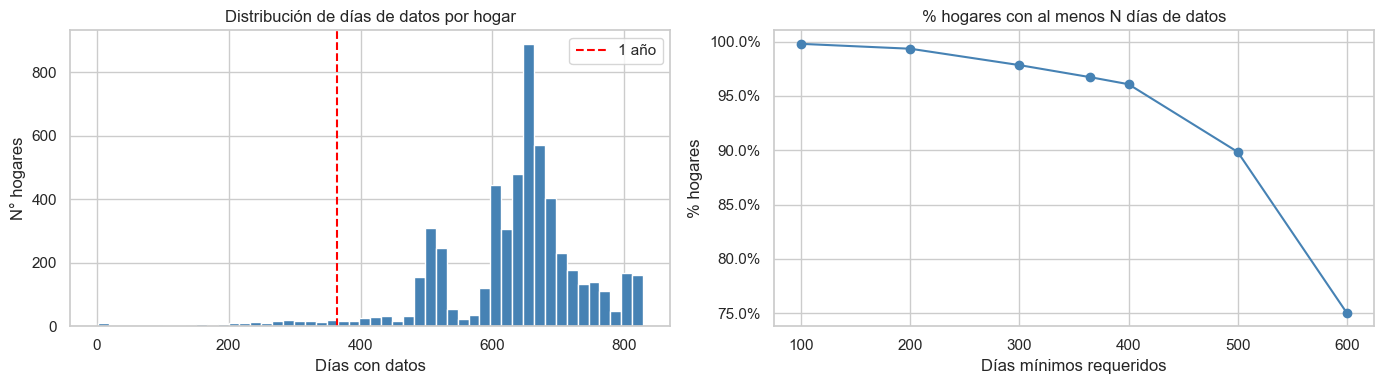

Percentiles de cobertura:
count    5566.0
mean      631.0
std       112.0
min         1.0
25%       600.0
50%       651.0
75%       684.0
max       829.0
Name: day, dtype: float64


In [11]:
dias_por_hogar = df_daily.groupby('LCLid')['day'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dias_por_hogar.hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(365, color='red', linestyle='--', label='1 año')
axes[0].set_title('Distribución de días de datos por hogar')
axes[0].set_xlabel('Días con datos')
axes[0].set_ylabel('N° hogares')
axes[0].legend()

# Acumulado
umbral_dias = [100, 200, 300, 365, 400, 500, 600]
pct_hogares = [( dias_por_hogar >= u).mean() * 100 for u in umbral_dias]
axes[1].plot(umbral_dias, pct_hogares, 'o-', color='steelblue')
axes[1].set_title('% hogares con al menos N días de datos')
axes[1].set_xlabel('Días mínimos requeridos')
axes[1].set_ylabel('% hogares')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

print(f'Percentiles de cobertura:')
print(dias_por_hogar.describe().round(0))

### 3.3 Filtrado de hogares con cobertura insuficiente

In [12]:
UMBRAL_DIAS = 365  # mínimo 1 año de datos

hogares_validos = dias_por_hogar[dias_por_hogar >= UMBRAL_DIAS].index
df_daily_clean = df_daily[df_daily['LCLid'].isin(hogares_validos)].copy()

print(f'Hogares originales:  {df_daily["LCLid"].nunique():,}')
print(f'Hogares con ≥{UMBRAL_DIAS} días: {len(hogares_validos):,}')
print(f'Hogares descartados: {df_daily["LCLid"].nunique() - len(hogares_validos):,}')
print(f'Registros finales:   {len(df_daily_clean):,}')

Hogares originales:  5,566
Hogares con ≥365 días: 5,384
Hogares descartados: 182
Registros finales:   3,464,152


---
## 4. 🛠️ Integración y Feature Engineering
### 4.1 Join con metadatos de hogares y clima

In [13]:
# Join con información de hogares
df = df_daily_clean.merge(
    df_hh[['LCLid', 'stdorToU', 'Acorn', 'Acorn_grouped']],
    on='LCLid',
    how='left'
)

# Join con clima
df = df.merge(df_weather, on='day', how='left')

# Verificar cobertura del join
print(f'Registros tras joins: {len(df):,}')
print(f'NaN en Acorn_grouped: {df["Acorn_grouped"].isnull().sum():,}')
print(f'NaN en temperatura:   {df["temperatureMax"].isnull().sum():,}')
print(f'\nDistribución por tarifa:')
print(df.drop_duplicates('LCLid')['stdorToU'].value_counts())
print(f'\nDistribución por grupo Acorn:')
print(df.drop_duplicates('LCLid')['Acorn_grouped'].value_counts())

Registros tras joins: 3,464,152
NaN en Acorn_grouped: 0
NaN en temperatura:   10,544

Distribución por tarifa:
stdorToU
Std    4289
ToU    1095
Name: count, dtype: int64

Distribución por grupo Acorn:
Acorn_grouped
Affluent       2114
Adversity      1754
Comfortable    1469
ACORN-U          46
ACORN-            1
Name: count, dtype: int64


### 4.2 Feature engineering temporal y climático

In [14]:
# ── Variables temporales ─────────────────────────────────────
df['month']      = df['day'].dt.month
df['day_of_week']= df['day'].dt.dayofweek   # 0=lunes
df['quarter']    = df['day'].dt.quarter
df['week']       = df['day'].dt.isocalendar().week.astype(int)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Estación del año (hemisferio norte — UK)
def estacion(m):
    if m in [12, 1, 2]:  return 'invierno'
    elif m in [3, 4, 5]: return 'primavera'
    elif m in [6, 7, 8]: return 'verano'
    else:                return 'otoño'

df['season'] = df['month'].apply(estacion)

# ── Temperatura media diaria ──────────────────────────────────
df['temp_mean'] = (df['temperatureMax'] + df['temperatureMin']) / 2

# Heating Degree Days (HDD) — proxy de necesidad de calefacción
# Base 15.5°C (estándar UK)
df['HDD'] = (15.5 - df['temp_mean']).clip(lower=0)

# ── Variables de consumo por hogar (lag y rolling) ────────────
# Ordenar para que los shifts sean correctos
df = df.sort_values(['LCLid', 'day'])

df['lag_1d']       = df.groupby('LCLid')['energy_sum'].shift(1)
df['lag_7d']       = df.groupby('LCLid')['energy_sum'].shift(7)
df['rolling_7d']   = df.groupby('LCLid')['energy_sum'].transform(
                         lambda x: x.shift(1).rolling(7, min_periods=3).mean())
df['rolling_30d']  = df.groupby('LCLid')['energy_sum'].transform(
                         lambda x: x.shift(1).rolling(30, min_periods=7).mean())
df['rolling_std_7d']= df.groupby('LCLid')['energy_sum'].transform(
                         lambda x: x.shift(1).rolling(7, min_periods=3).std())

# Consumo relativo al promedio histórico del hogar
consumo_promedio_hogar = df.groupby('LCLid')['energy_sum'].transform('mean')
df['energy_vs_mean'] = df['energy_sum'] / consumo_promedio_hogar

# Eliminar NaN de lags (primeros días de cada hogar)
df_model = df.dropna(subset=['lag_1d', 'lag_7d', 'rolling_7d', 'rolling_30d']).copy()

print(f'Dataset final para modelos: {df_model.shape}')
print(f'Hogares: {df_model["LCLid"].nunique():,}')
print(f'Columnas: {df_model.columns.tolist()}')

Dataset final para modelos: (3426461, 33)
Hogares: 5,384
Columnas: ['LCLid', 'day', 'energy_median', 'energy_mean', 'energy_max', 'energy_count', 'energy_std', 'energy_sum', 'energy_min', 'stdorToU', 'Acorn', 'Acorn_grouped', 'temperatureMax', 'temperatureMin', 'humidity', 'windSpeed', 'cloudCover', 'pressure', 'uvIndex', 'month', 'day_of_week', 'quarter', 'week', 'is_weekend', 'season', 'temp_mean', 'HDD', 'lag_1d', 'lag_7d', 'rolling_7d', 'rolling_30d', 'rolling_std_7d', 'energy_vs_mean']


---
## 5. 📊 EDA
### 5.1 Distribución general del consumo

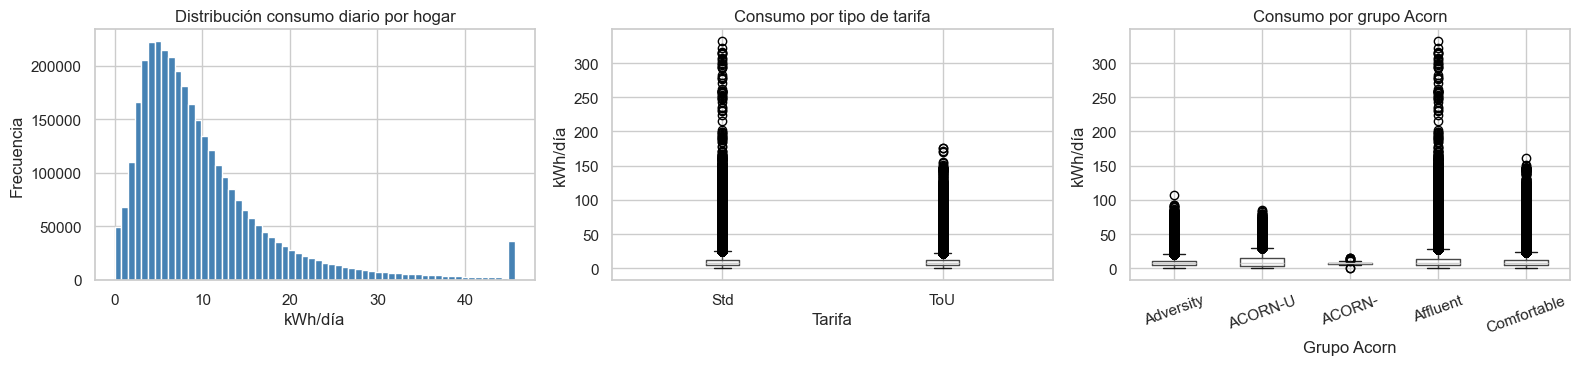


Estadísticas descriptivas:
count    3426461.000
mean          10.133
std            9.099
min            0.000
25%            4.692
50%            7.829
75%           12.581
max          332.556
Name: energy_sum, dtype: float64

Test Mann-Whitney (ToU vs Std): p=0.0000e+00
→ Diferencia estadísticamente significativa


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma consumo diario
df_model['energy_sum'].clip(upper=df_model['energy_sum'].quantile(0.99)).hist(
    bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución consumo diario por hogar')
axes[0].set_xlabel('kWh/día')
axes[0].set_ylabel('Frecuencia')

# Boxplot por tarifa
df_model.boxplot(column='energy_sum', by='stdorToU', ax=axes[1])
axes[1].set_title('Consumo por tipo de tarifa')
axes[1].set_xlabel('Tarifa')
axes[1].set_ylabel('kWh/día')
plt.sca(axes[1]); plt.title('Consumo por tipo de tarifa')

# Boxplot por grupo Acorn
order_acorn = df_model.groupby('Acorn_grouped')['energy_sum'].median().sort_values().index
# Convert 'Acorn_grouped' to a categorical type with the desired order
df_model['Acorn_grouped'] = pd.Categorical(df_model['Acorn_grouped'], categories=order_acorn, ordered=True)
df_model.boxplot(column='energy_sum', by='Acorn_grouped', ax=axes[2])
axes[2].set_title('Consumo por grupo socioeconómico')
axes[2].set_xlabel('Grupo Acorn')
axes[2].set_ylabel('kWh/día')
plt.sca(axes[2]); plt.title('Consumo por grupo Acorn')
plt.xticks(rotation=20)

plt.suptitle('')
plt.tight_layout()
plt.show()

print('\nEstadísticas descriptivas:')
print(df_model['energy_sum'].describe().round(3))

# Test estadístico: ¿difiere el consumo entre tarifas?
tou = df_model[df_model['stdorToU']=='ToU']['energy_sum'].dropna()
std = df_model[df_model['stdorToU']=='Std']['energy_sum'].dropna()
stat, p = stats.mannwhitneyu(tou, std, alternative='two-sided')
print(f'\nTest Mann-Whitney (ToU vs Std): p={p:.4e}')
print('→ Diferencia estadísticamente significativa' if p < 0.05 else '→ Sin diferencia significativa')

### 5.2 Patrones temporales agregados

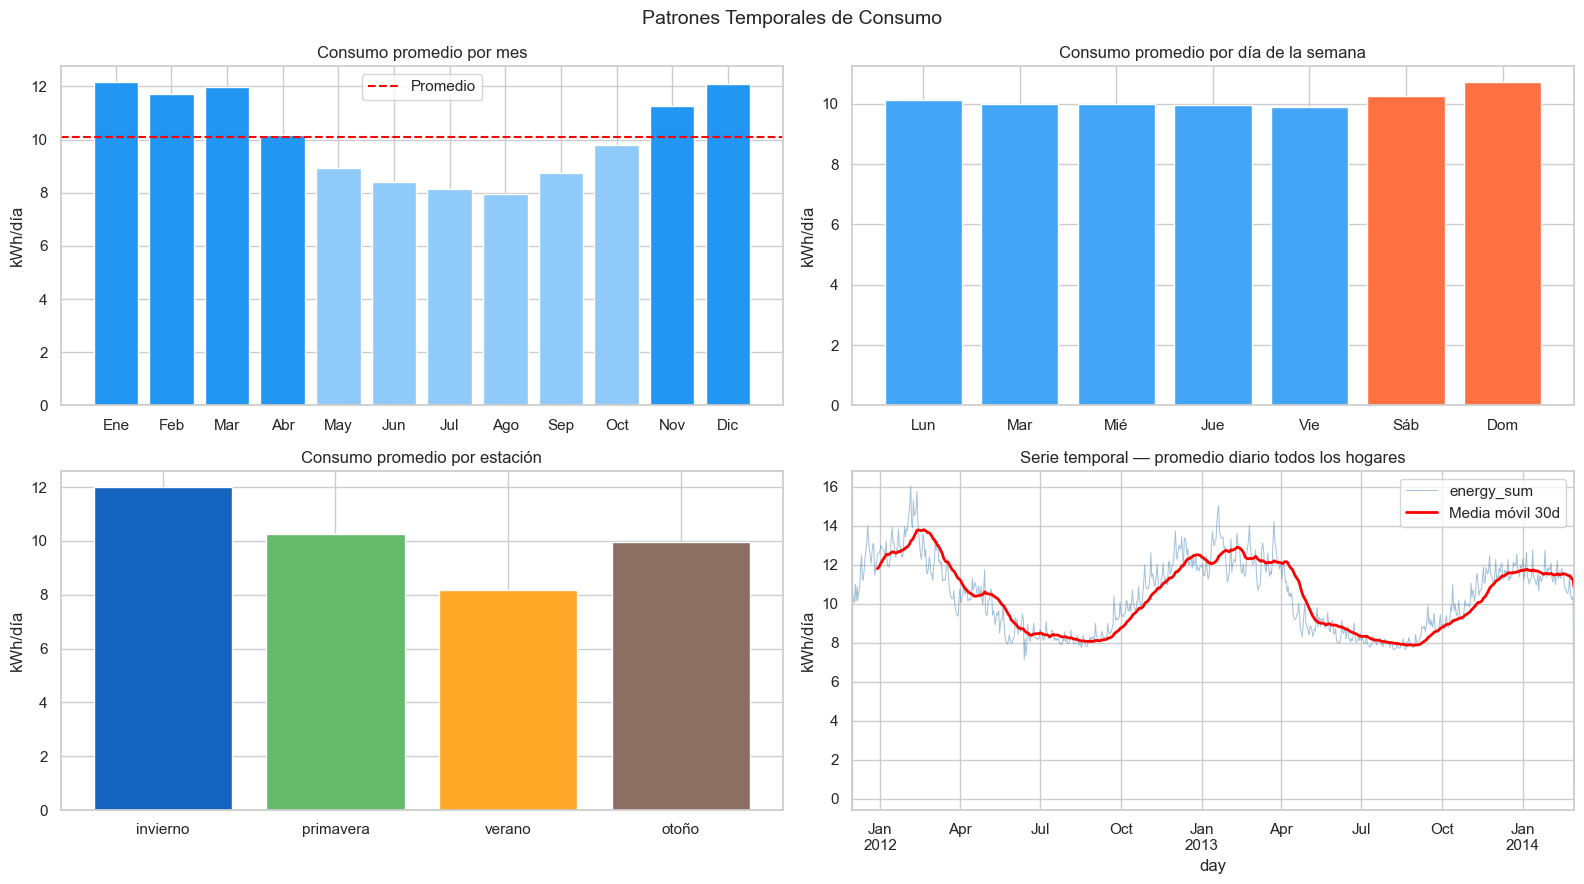

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Por mes
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
monthly = df_model.groupby('month')['energy_sum'].mean()
colors_m = ['#2196F3' if v > monthly.mean() else '#90CAF9' for v in monthly]
axes[0,0].bar([meses[m-1] for m in monthly.index], monthly.values, color=colors_m)
axes[0,0].axhline(monthly.mean(), color='red', linestyle='--', label='Promedio')
axes[0,0].set_title('Consumo promedio por mes')
axes[0,0].set_ylabel('kWh/día')
axes[0,0].legend()

# Por día de la semana
dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
weekly = df_model.groupby('day_of_week')['energy_sum'].mean()
colors_w = ['#FF7043' if i >= 5 else '#42A5F5' for i in range(7)]
axes[0,1].bar(dias, weekly.values, color=colors_w)
axes[0,1].set_title('Consumo promedio por día de la semana')
axes[0,1].set_ylabel('kWh/día')

# Por estación
seasonal = df_model.groupby('season')['energy_sum'].mean().reindex(
    ['invierno', 'primavera', 'verano', 'otoño'])
colors_s = ['#1565C0', '#66BB6A', '#FFA726', '#8D6E63']
axes[1,0].bar(seasonal.index, seasonal.values, color=colors_s)
axes[1,0].set_title('Consumo promedio por estación')
axes[1,0].set_ylabel('kWh/día')

# Serie temporal global (promedio diario de todos los hogares)
daily_global = df_model.groupby('day')['energy_sum'].mean()
daily_global.plot(ax=axes[1,1], color='steelblue', alpha=0.5, linewidth=0.7)
daily_global.rolling(30).mean().plot(ax=axes[1,1], color='red',
                                      linewidth=2, label='Media móvil 30d')
axes[1,1].set_title('Serie temporal — promedio diario todos los hogares')
axes[1,1].set_ylabel('kWh/día')
axes[1,1].legend()

plt.suptitle('Patrones Temporales de Consumo', fontsize=14)
plt.tight_layout()
plt.show()

### 5.3 Perfil intradiario (cada 30 min)

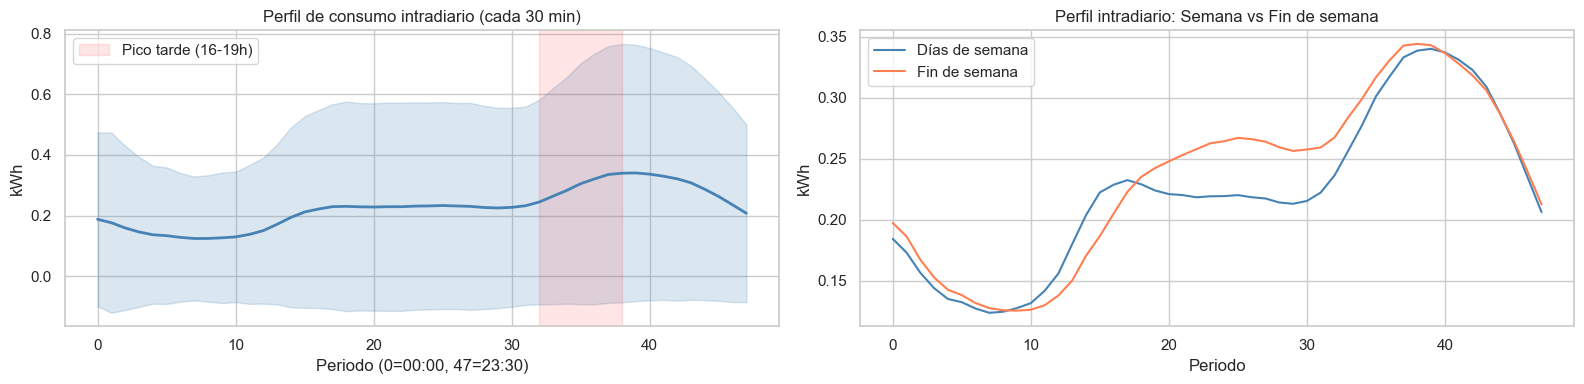

In [17]:
# Agregar consumo por periodo del día
intra_avg = df_intra_long.groupby('period_num')['energy_kwh'].agg(['mean','std']).reset_index()
intra_avg['hora_label'] = (intra_avg['period_num'] * 0.5).apply(
    lambda h: f"{int(h):02d}:{int((h%1)*60):02d}")

# Separar fin de semana vs semana
df_intra_long['is_weekend'] = df_intra_long['day'].dt.dayofweek >= 5
intra_semana = df_intra_long[~df_intra_long['is_weekend']].groupby('period_num')['energy_kwh'].mean()
intra_finde  = df_intra_long[df_intra_long['is_weekend']].groupby('period_num')['energy_kwh'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Perfil promedio
x = intra_avg['period_num']
axes[0].plot(x, intra_avg['mean'], color='steelblue', linewidth=2)
axes[0].fill_between(x,
    intra_avg['mean'] - intra_avg['std'],
    intra_avg['mean'] + intra_avg['std'],
    alpha=0.2, color='steelblue')
axes[0].set_title('Perfil de consumo intradiario (cada 30 min)')
axes[0].set_xlabel('Periodo (0=00:00, 47=23:30)')
axes[0].set_ylabel('kWh')
# Marcar horas pico
axes[0].axvspan(32, 38, alpha=0.1, color='red', label='Pico tarde (16-19h)')
axes[0].legend()

# Semana vs fin de semana
axes[1].plot(intra_semana.index, intra_semana.values, label='Días de semana', color='steelblue')
axes[1].plot(intra_finde.index, intra_finde.values, label='Fin de semana', color='coral')
axes[1].set_title('Perfil intradiario: Semana vs Fin de semana')
axes[1].set_xlabel('Periodo')
axes[1].set_ylabel('kWh')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.4 Relación consumo vs temperatura

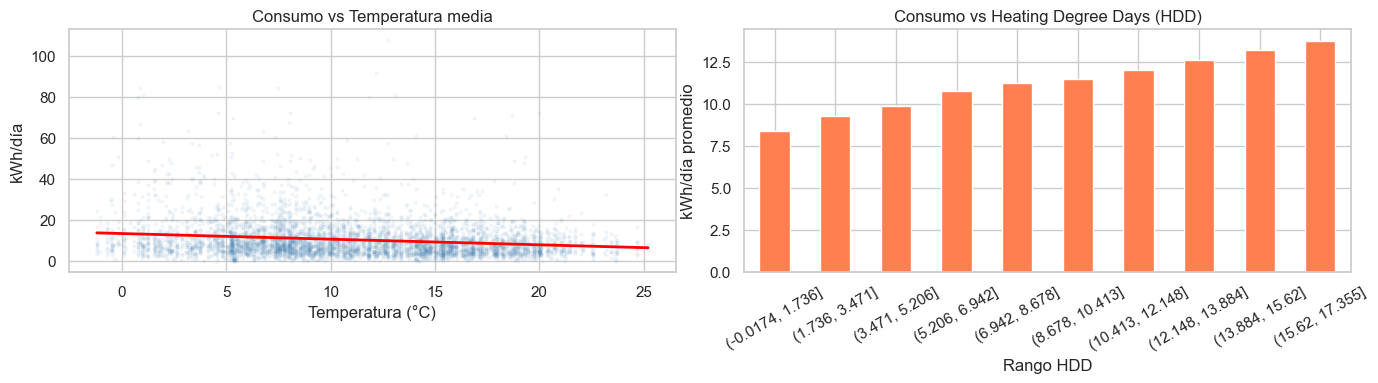

Correlación consumo vs temperatura media: -0.1718
Correlación consumo vs HDD:               0.1740


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Scatter consumo vs temperatura (muestra para visualización)
sample = df_model.sample(min(5000, len(df_model)), random_state=42)
axes[0].scatter(sample['temp_mean'], sample['energy_sum'],
                alpha=0.05, s=5, color='steelblue')

# Línea de tendencia
z = np.polyfit(sample.dropna(subset=['temp_mean'])['temp_mean'],
               sample.dropna(subset=['temp_mean'])['energy_sum'], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(sample['temp_mean'].min(), sample['temp_mean'].max(), 100)
axes[0].plot(x_line, p_fit(x_line), color='red', linewidth=2)
axes[0].set_title('Consumo vs Temperatura media')
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('kWh/día')

# Consumo vs HDD (Heating Degree Days)
hdd_avg = df_model.groupby('HDD'.split()[0])['energy_sum'].mean() if False else \
          df_model.groupby(pd.cut(df_model['HDD'], bins=10))['energy_sum'].mean()
hdd_avg.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Consumo vs Heating Degree Days (HDD)')
axes[1].set_xlabel('Rango HDD')
axes[1].set_ylabel('kWh/día promedio')
plt.sca(axes[1]); plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Correlación con temperatura
corr_temp = df_model['energy_sum'].corr(df_model['temp_mean'])
corr_hdd  = df_model['energy_sum'].corr(df_model['HDD'])
print(f'Correlación consumo vs temperatura media: {corr_temp:.4f}')
print(f'Correlación consumo vs HDD:               {corr_hdd:.4f}')

### 5.5 Heterogeneidad entre hogares
> Esta sección es clave para justificar el clustering como modelo.

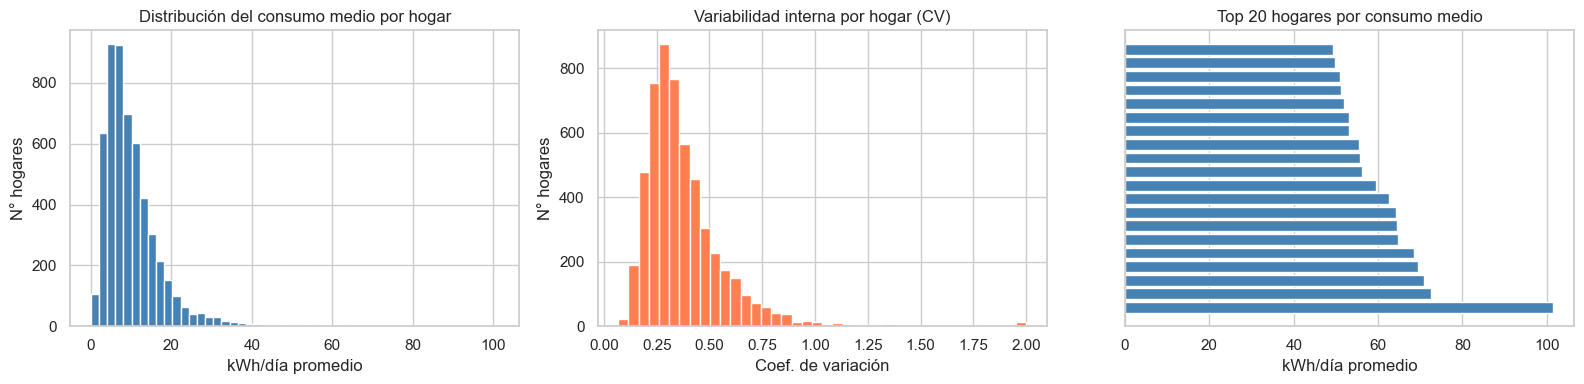


Rango de consumo entre hogares:
  Mínimo promedio: 0.00 kWh/día
  Máximo promedio: 101.37 kWh/día
  Ratio max/min:   Indefinido (mínimo consumo promedio es 0)

→ Alta heterogeneidad justifica clustering por perfil de consumo


In [19]:
# Consumo promedio por hogar
hogar_stats = df_model.groupby('LCLid').agg(
    consumo_medio=('energy_sum', 'mean'),
    consumo_std=('energy_sum', 'std'),
    consumo_max=('energy_sum', 'max'),
    consumo_min=('energy_sum', 'min')
).reset_index()
hogar_stats['cv'] = hogar_stats['consumo_std'] / hogar_stats['consumo_medio']  # coef. variación

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución del consumo medio por hogar
hogar_stats['consumo_medio'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del consumo medio por hogar')
axes[0].set_xlabel('kWh/día promedio')
axes[0].set_ylabel('N° hogares')

# Coeficiente de variación (variabilidad interna)
hogar_stats['cv'].clip(upper=2).hist(bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Variabilidad interna por hogar (CV)')
axes[1].set_xlabel('Coef. de variación')
axes[1].set_ylabel('N° hogares')

# Top 20 hogares más consumidores
top20 = hogar_stats.nlargest(20, 'consumo_medio')
axes[2].barh(range(20), top20['consumo_medio'].values, color='steelblue')
axes[2].set_title('Top 20 hogares por consumo medio')
axes[2].set_xlabel('kWh/día promedio')
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

min_consumo = hogar_stats["consumo_medio"].min()
max_consumo = hogar_stats["consumo_medio"].max()

print(f'\nRango de consumo entre hogares:')
print(f'  Mínimo promedio: {min_consumo:.2f} kWh/día')
print(f'  Máximo promedio: {max_consumo:.2f} kWh/día')

if min_consumo == 0:
    print(f'  Ratio max/min:   Indefinido (mínimo consumo promedio es 0)')
else:
    print(f'  Ratio max/min:   {max_consumo / min_consumo:.1f}x')
print(f'\n→ Alta heterogeneidad justifica clustering por perfil de consumo')


### 5.6 Detección preliminar de anomalías por hogar

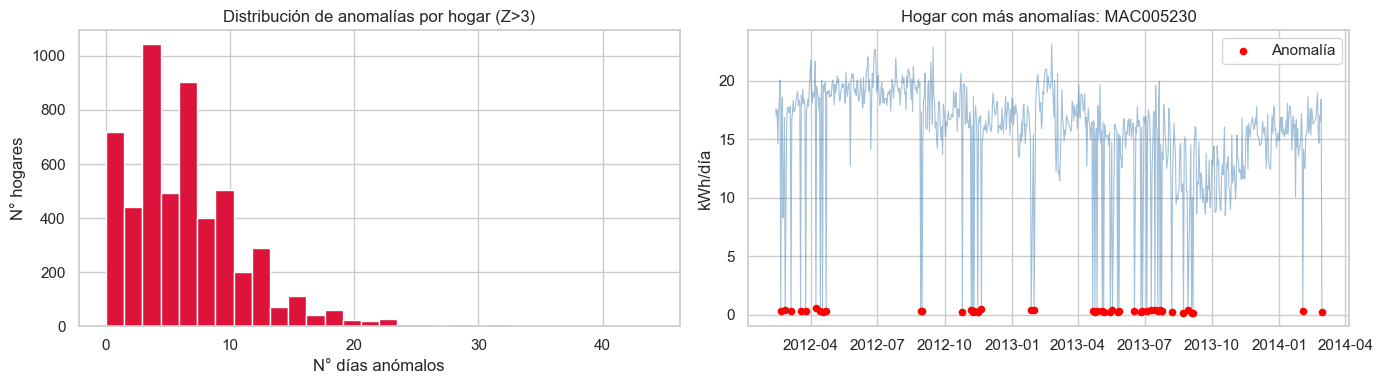

Total registros anómalos: 34,127 (1.00%)
Hogares con ≥5 días anómalos: 3,182


In [20]:
# Anomalía = consumo > media_hogar + 3*std_hogar
df_model['z_score_hogar'] = df_model.groupby('LCLid')['energy_sum'].transform(
    lambda x: (x - x.mean()) / x.std()
)
df_model['is_anomaly_zscore'] = (df_model['z_score_hogar'].abs() > 3).astype(int)

anomalias_por_hogar = df_model.groupby('LCLid')['is_anomaly_zscore'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

anomalias_por_hogar.hist(bins=30, ax=axes[0], color='crimson', edgecolor='white')
axes[0].set_title('Distribución de anomalías por hogar (Z>3)')
axes[0].set_xlabel('N° días anómalos')
axes[0].set_ylabel('N° hogares')

# Visualizar un hogar con muchas anomalías
hogar_anomalo = anomalias_por_hogar.idxmax()
data_hogar = df_model[df_model['LCLid'] == hogar_anomalo]
axes[1].plot(data_hogar['day'], data_hogar['energy_sum'],
             alpha=0.5, color='steelblue', linewidth=0.8)
anomalias_hogar = data_hogar[data_hogar['is_anomaly_zscore'] == 1]
axes[1].scatter(anomalias_hogar['day'], anomalias_hogar['energy_sum'],
                color='red', s=20, zorder=5, label='Anomalía')
axes[1].set_title(f'Hogar con más anomalías: {hogar_anomalo}')
axes[1].set_ylabel('kWh/día')
axes[1].legend()

plt.tight_layout()
plt.show()

total_anomalias = df_model['is_anomaly_zscore'].sum()
pct = total_anomalias / len(df_model) * 100
print(f'Total registros anómalos: {total_anomalias:,} ({pct:.2f}%)')
print(f'Hogares con ≥5 días anómalos: {(anomalias_por_hogar >= 5).sum():,}')

### 5.7 Matriz de correlaciones

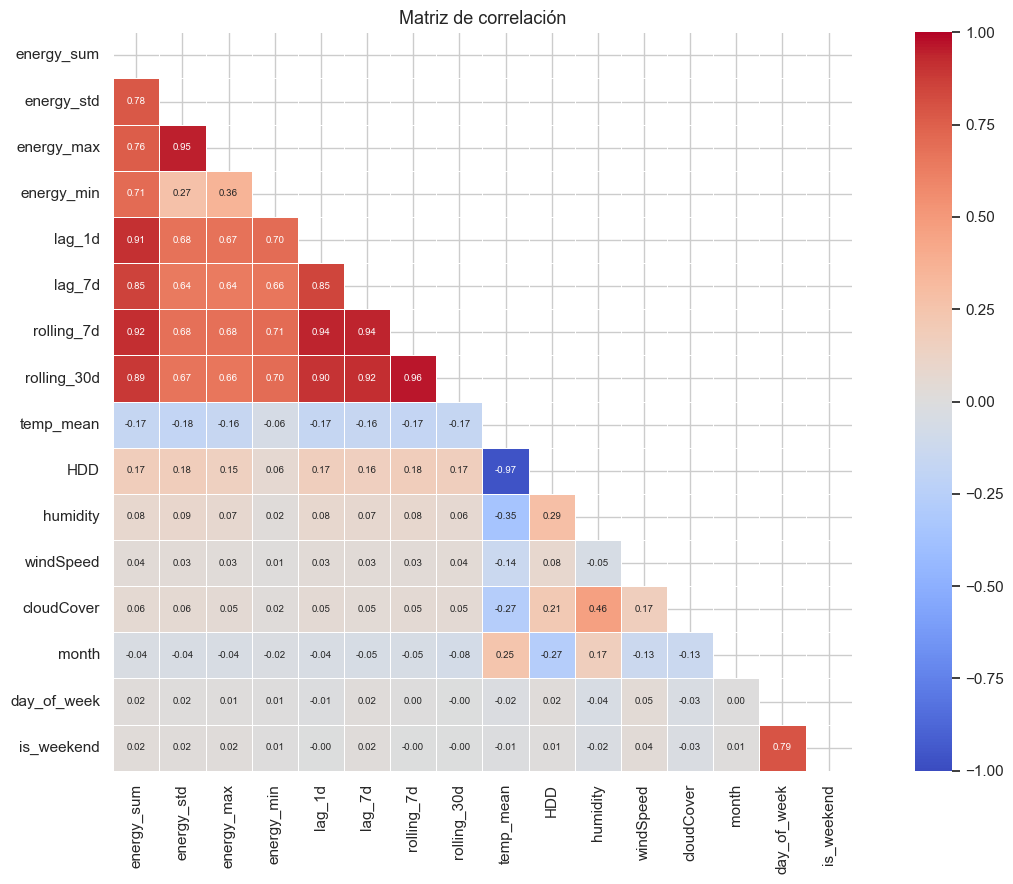


Top correlaciones con energy_sum:
rolling_7d     0.9150
lag_1d         0.9083
rolling_30d    0.8904
lag_7d         0.8545
energy_std     0.7775
energy_max     0.7639
energy_min     0.7107
HDD            0.1740
temp_mean     -0.1718
humidity       0.0799
Name: energy_sum, dtype: float64


In [21]:
cols_corr = ['energy_sum', 'energy_std', 'energy_max', 'energy_min',
             'lag_1d', 'lag_7d', 'rolling_7d', 'rolling_30d',
             'temp_mean', 'HDD', 'humidity', 'windSpeed', 'cloudCover',
             'month', 'day_of_week', 'is_weekend']

corr = df_model[cols_corr].corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.4, vmin=-1, vmax=1,
            annot_kws={'size': 7})
plt.title('Matriz de correlación', fontsize=13)
plt.tight_layout()
plt.show()

# Top correlaciones con target
target_corr = corr['energy_sum'].drop('energy_sum').sort_values(key=abs, ascending=False)
print('\nTop correlaciones con energy_sum:')
print(target_corr.head(10).round(4))

---
## 6. ✅ Selección de variables
### 6.1 Importancia con Random Forest

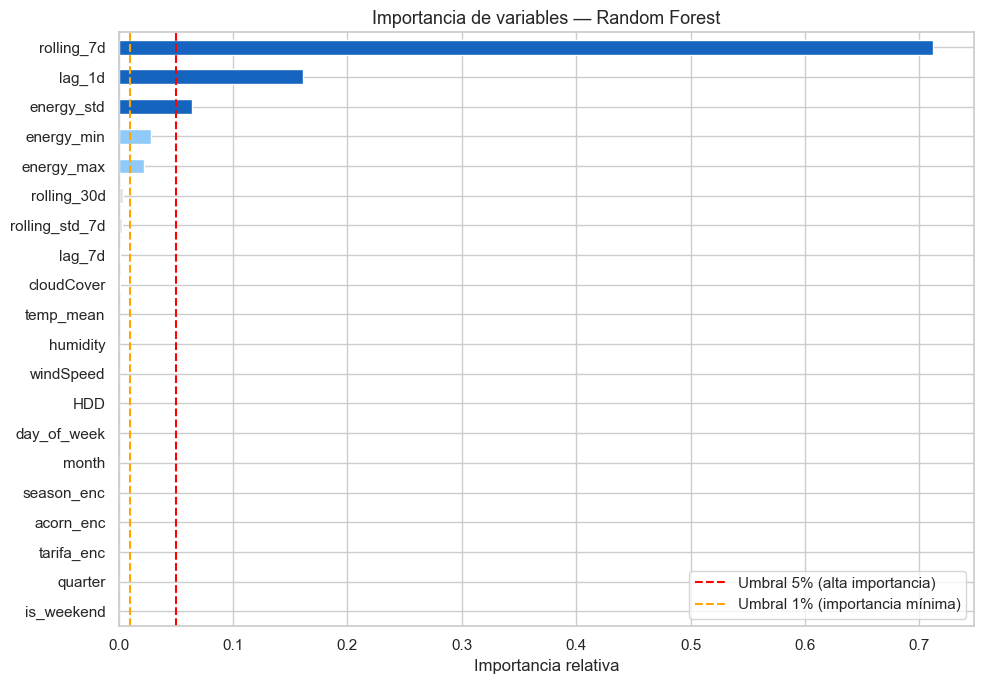


Importancia por variable:
rolling_7d        0.7122
lag_1d            0.1612
energy_std        0.0639
energy_min        0.0281
energy_max        0.0222
rolling_30d       0.0036
rolling_std_7d    0.0032
lag_7d            0.0013
cloudCover        0.0009
temp_mean         0.0007
humidity          0.0006
windSpeed         0.0006
HDD               0.0005
day_of_week       0.0003
month             0.0003
season_enc        0.0002
acorn_enc         0.0001
tarifa_enc        0.0001
quarter           0.0001
is_weekend        0.0001
dtype: float64


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Codificar categóricas
le_tarifa = LabelEncoder()
le_acorn  = LabelEncoder()
le_season = LabelEncoder()

df_model['tarifa_enc'] = le_tarifa.fit_transform(df_model['stdorToU'].fillna('Std'))
# Convert 'Acorn_grouped' to object dtype before fillna to allow adding new category, then encode
df_model['acorn_enc']  = le_acorn.fit_transform(df_model['Acorn_grouped'].astype(object).fillna('Unknown'))
df_model['season_enc'] = le_season.fit_transform(df_model['season'])

feature_candidates = [
    # Lags y rolling
    'lag_1d', 'lag_7d', 'rolling_7d', 'rolling_30d', 'rolling_std_7d',
    # Temporales
    'month', 'day_of_week', 'is_weekend', 'quarter', 'season_enc',
    # Clima
    'temp_mean', 'HDD', 'humidity', 'windSpeed', 'cloudCover',
    # Estadísticas del hogar
    'energy_std', 'energy_max', 'energy_min',
    # Categorías
    'tarifa_enc', 'acorn_enc'
]

df_rf = df_model[feature_candidates + ['energy_sum']].dropna()
X = df_rf[feature_candidates]
y = df_rf['energy_sum']

# Muestra para agilizar (100k registros es suficiente)
idx = np.random.choice(len(X), min(100_000, len(X)), replace=False)
X_s, y_s = X.iloc[idx], y.iloc[idx]

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_s, y_s)

importances = pd.Series(rf.feature_importances_, index=feature_candidates).sort_values()

plt.figure(figsize=(10, 7))
colors_imp = ['#1565C0' if v >= 0.05 else '#90CAF9' if v >= 0.01 else '#E0E0E0'
              for v in importances]
importances.plot(kind='barh', color=colors_imp)
plt.axvline(0.05, color='red', linestyle='--', label='Umbral 5% (alta importancia)')
plt.axvline(0.01, color='orange', linestyle='--', label='Umbral 1% (importancia mínima)')
plt.title('Importancia de variables — Random Forest', fontsize=13)
plt.xlabel('Importancia relativa')
plt.legend()
plt.tight_layout()
plt.show()

print('\nImportancia por variable:')
print(importances.sort_values(ascending=False).round(4))

### 6.2 Definición final de grupos de variables por modelo

In [29]:
# ── Modelo 1: Regresión — Predicción de consumo diario ────────────────
FEATURES_REGRESSION = [
    'lag_1d', 'lag_7d', 'rolling_7d', 'rolling_30d', 'rolling_std_7d',
    'month', 'day_of_week', 'is_weekend', 'season_enc',
    'temp_mean', 'HDD', 'humidity', 'cloudCover',
    'tarifa_enc', 'acorn_enc'
]
TARGET_REGRESSION = 'energy_sum'

# ── Modelo 2: Detección de anomalías — Isolation Forest ───────────────
# Usamos features a nivel de hogar-día para detectar días inusuales
FEATURES_ANOMALY = [
    'energy_sum', 'energy_vs_mean',
    'rolling_7d', 'rolling_std_7d',
    'temp_mean', 'HDD',
    'month', 'is_weekend'
]

# ── Modelo 3: Clustering — Segmentación de hogares ────────────────────
# Agregamos a nivel de hogar (un vector por hogar)
hogar_perfil = df_model.groupby('LCLid').agg(
    consumo_total   = ('energy_sum', 'sum'),
    consumo_medio   = ('energy_sum', 'mean'),
    consumo_std     = ('energy_sum', 'std'),
    consumo_max     = ('energy_sum', 'max'),
    consumo_invierno= ('energy_sum', lambda x: x[df_model.loc[x.index,'season']=='invierno'].mean()),
    consumo_verano  = ('energy_sum', lambda x: x[df_model.loc[x.index,'season']=='verano'].mean()),
    consumo_finde   = ('energy_sum', lambda x: x[df_model.loc[x.index,'is_weekend']==1].mean()),
    consumo_semana  = ('energy_sum', lambda x: x[df_model.loc[x.index,'is_weekend']==0].mean()),
    ratio_invierno_verano = ('energy_sum', lambda x: (
        x[df_model.loc[x.index,'season']=='invierno'].mean() /
        (x[df_model.loc[x.index,'season']=='verano'].mean() + 1e-6)
    )),
    dias_registrados = ('day', 'nunique')
).reset_index()

# Añadir tarifa y acorn al perfil
hogar_perfil = hogar_perfil.merge(
    df_model[['LCLid','stdorToU','Acorn_grouped','tarifa_enc','acorn_enc']].drop_duplicates('LCLid'),
    on='LCLid', how='left'
)

FEATURES_CLUSTERING = [
    'consumo_total', 'consumo_medio', 'consumo_std', 'consumo_max',
    'consumo_invierno', 'consumo_verano', 'consumo_finde', 'consumo_semana',
    'ratio_invierno_verano', 'dias_registrados'
]

print('=== Grupos de variables definidos ===')
print(f'\nRegresión  ({len(FEATURES_REGRESSION)} features):')
print(f'  {FEATURES_REGRESSION}')
print(f'\nAnomalías  ({len(FEATURES_ANOMALY)} features):')
print(f'  {FEATURES_ANOMALY}')
print(f'\nClustering ({len(FEATURES_CLUSTERING)} features, nivel hogar):')
print(f'  {FEATURES_CLUSTERING}')
print(f'\nHogares en perfil para clustering: {len(hogar_perfil):,}')

=== Grupos de variables definidos ===

Regresión  (15 features):
  ['lag_1d', 'lag_7d', 'rolling_7d', 'rolling_30d', 'rolling_std_7d', 'month', 'day_of_week', 'is_weekend', 'season_enc', 'temp_mean', 'HDD', 'humidity', 'cloudCover', 'tarifa_enc', 'acorn_enc']

Anomalías  (8 features):
  ['energy_sum', 'energy_vs_mean', 'rolling_7d', 'rolling_std_7d', 'temp_mean', 'HDD', 'month', 'is_weekend']

Clustering (10 features, nivel hogar):
  ['consumo_total', 'consumo_medio', 'consumo_std', 'consumo_max', 'consumo_invierno', 'consumo_verano', 'consumo_finde', 'consumo_semana', 'ratio_invierno_verano', 'dias_registrados']

Hogares en perfil para clustering: 5,384


---
## 7. 💾 Guardar datasets procesados

In [30]:
# Dataset principal para regresión y anomalías
df_model.to_csv('smart_meters_model_ready.csv', index=False)

# Perfil por hogar para clustering
hogar_perfil.to_csv('smart_meters_hogar_perfil.csv', index=False)

print('✅ Archivos guardados:')
print(f'  smart_meters_model_ready.csv  — {len(df_model):,} registros, {len(df_model.columns)} columnas')
print(f'  smart_meters_hogar_perfil.csv — {len(hogar_perfil):,} hogares,  {len(hogar_perfil.columns)} columnas')

✅ Archivos guardados:
  smart_meters_model_ready.csv  — 3,426,461 registros, 38 columnas
  smart_meters_hogar_perfil.csv — 5,384 hogares,  15 columnas


---
## 8. 📋 Resumen ejecutivo del EDA

In [32]:
n_hogares   = df_model['LCLid'].nunique()
n_dias      = df_model['day'].nunique()
consumo_med = df_model['energy_sum'].mean()
consumo_max = df_model['energy_sum'].max()
n_anomalias = df_model['is_anomaly_zscore'].sum()
pct_anomaly = n_anomalias / len(df_model) * 100

min_consumo_perfil = hogar_perfil['consumo_medio'].min()
max_consumo_perfil = hogar_perfil['consumo_medio'].max()

if min_consumo_perfil == 0:
    ratio_max_str = 'Indefinido'
    ratio_max = 0 # Assign a default numeric value or handle as string later
else:
    ratio_max = max_consumo_perfil / min_consumo_perfil
    ratio_max_str = f'{ratio_max:.1f}x'

print('=' * 65)
print('   RESUMEN EJECUTIVO — Smart Meters London EDA')
print('=' * 65)
print(f'''
📊 DATOS
  • Hogares analizados:  {n_hogares:,}
  • Días con datos:      {n_dias:,}
  • Registros totales:   {len(df_model):,}
  • Período:             {df_model["day"].min().date()} → {df_model["day"].max().date()}

⚡ CONSUMO
  • Promedio diario:     {consumo_med:.2f} kWh/hogar/día
  • Máximo registrado:   {consumo_max:.2f} kWh/día
  • Ratio mayor/menor:   {ratio_max_str} entre hogares

🌡️ FACTORES CLAVE IDENTIFICADOS
  • Temperatura (HDD) explica la mayor parte de la variación estacional
  • Invierno consume ~2x más que verano
  • Pico de demanda intradiario: 16:00-19:00h
  • Hogares ToU muestran mayor sensibilidad horaria

🔴 ANOMALÍAS (Z > 3)
  • Registros anómalos: {n_anomalias:,} ({pct_anomaly:.2f}%)
  • Alta variabilidad entre hogares → Isolation Forest viable

🏗️ VARIABLES MÁS IMPORTANTES (Random Forest)
  • Lags temporales (lag_1d, lag_7d) — mayor poder predictivo
  • HDD y temperatura media — efecto climático significativo
  • Rolling means — capturan tendencia del hogar
  • Tarifa (ToU vs Std) — diferencia estadísticamente significativa

✅ JUSTIFICACIÓN DE LOS 3 MODELOS
  1. REGRESIÓN:   Alta autocorrelación + efecto temperatura → predecible
  2. ANOMALÍAS:   {pct_anomaly:.1f}% días anómalos → detección viable con Isolation Forest
  3. CLUSTERING:  Ratio {ratio_max_str} entre hogares → segmentación necesaria y válida

➡️  PRÓXIMOS PASOS
  • Notebook 2: Random Forest + XGBoost para regresión
  • Notebook 3: Isolation Forest para anomalías
  • Notebook 4: K-Means + PCA sobre perfil de hogares
  • Notebook 5: Dashboard Streamlit con alertas y predicciones
''')
print('=' * 65)


   RESUMEN EJECUTIVO — Smart Meters London EDA

📊 DATOS
  • Hogares analizados:  5,384
  • Días con datos:      822
  • Registros totales:   3,426,461
  • Período:             2011-11-30 → 2014-02-28

⚡ CONSUMO
  • Promedio diario:     10.13 kWh/hogar/día
  • Máximo registrado:   332.56 kWh/día
  • Ratio mayor/menor:   Indefinido entre hogares

🌡️ FACTORES CLAVE IDENTIFICADOS
  • Temperatura (HDD) explica la mayor parte de la variación estacional
  • Invierno consume ~2x más que verano
  • Pico de demanda intradiario: 16:00-19:00h
  • Hogares ToU muestran mayor sensibilidad horaria

🔴 ANOMALÍAS (Z > 3)
  • Registros anómalos: 34,127 (1.00%)
  • Alta variabilidad entre hogares → Isolation Forest viable

🏗️ VARIABLES MÁS IMPORTANTES (Random Forest)
  • Lags temporales (lag_1d, lag_7d) — mayor poder predictivo
  • HDD y temperatura media — efecto climático significativo
  • Rolling means — capturan tendencia del hogar
  • Tarifa (ToU vs Std) — diferencia estadísticamente significativa

✅ 